## Modelos de Clustering


El objetivo de esta etapa es segmentar las entidades financieras en grupos homogéneos de acuerdo con sus características financieras.

A partir del PCA se obtuvieron dos representaciones alternativas del conjunto de datos:

- **PC1–PC11:** aproximadamente 80% de la varianza acumulada.
- **PC1–PC15:** aproximadamente 91% de la varianza acumulada.

Ambas representaciones serán evaluadas mediante el algoritmo **K-Means**, con el propósito de determinar cuál permite obtener una segmentación más consistente, estable e interpretable de las entidades financieras.

## 1. Concepto de clustering



El **clustering** es una técnica de aprendizaje automático no supervisado cuyo objetivo es dividir un conjunto de observaciones en grupos o *clusters*, de manera que las observaciones pertenecientes a un mismo grupo sean lo más similares posible entre sí y, al mismo tiempo, diferentes de las observaciones pertenecientes a otros grupos.

A diferencia de un problema de clasificación supervisada, en clustering no se dispone previamente de una variable objetivo que indique a qué grupo pertenece cada observación. Los grupos son identificados a partir de la estructura de los datos.

En este proyecto, cada observación corresponde a una combinación **entidad financiera–año–mes**, y las variables utilizadas para formar los grupos corresponden a las componentes principales obtenidas mediante PCA.

Por tanto, el objetivo es identificar grupos de observaciones que presenten **perfiles financieros similares**, para posteriormente analizar qué características financieras distinguen a cada grupo y qué entidades presentan mayor presencia en cada uno.

La secuencia metodológica es:

$$
\text{Indicadores financieros}
\rightarrow
\text{PCA}
\rightarrow
\text{Espacio reducido}
\rightarrow
\text{K-Means}
\rightarrow
\text{Clusters}
\rightarrow
\text{Caracterización financiera}
$$

## 2. Fundamento matemático de K-Means



El algoritmo **K-Means** busca dividir las observaciones en $K$ grupos, asignando cada observación al centroide más cercano.

Sea:

$$
X = \{x_1,x_2,\ldots,x_n\}
$$

donde cada observación $x_i$ representa el perfil financiero de una observación entidad–período en el espacio reducido de componentes principales.

Si se utilizan las primeras $p$ componentes, entonces:

$$
x_i \in \mathbb{R}^{p}
$$

El algoritmo busca encontrar $K$ centroides:

$$
\mu_1,\mu_2,\ldots,\mu_K
$$

que permitan minimizar la suma de las distancias cuadráticas entre cada observación y el centroide del cluster al que pertenece.

La función objetivo de K-Means es:

$$
\boxed{
J = \sum_{k=1}^{K}\sum_{x_i\in C_k}
\|x_i-\mu_k\|^2
}
$$

donde:

- $C_k$ representa el cluster $k$.
- $\mu_k$ representa el centroide del cluster $k$.
- $\|x_i-\mu_k\|^2$ corresponde a la distancia euclídea cuadrática entre una observación y el centroide de su cluster.
- $J$ representa la suma total de cuadrados intra-cluster.

El algoritmo busca minimizar esta función. Por tanto, una solución adecuada debe generar grupos con **baja variabilidad interna**.

### ¿Cómo funciona K-Means?

El procedimiento puede resumirse en cuatro pasos:

1. Se seleccionan inicialmente $K$ centroides.
2. Cada observación se asigna al centroide más cercano.
3. Se recalculan los centroides como la media de las observaciones asignadas a cada grupo.
4. Se repiten los pasos 2 y 3 hasta que las asignaciones o los centroides convergen.

El centroide de un cluster se calcula como:

$$
\boxed{
\mu_k =
\frac{1}{|C_k|}
\sum_{x_i\in C_k}x_i
}
$$

Por tanto, el centroide representa el **perfil promedio** de las observaciones pertenecientes a cada cluster.

En este proyecto, el K-Means se aplica sobre las componentes principales y no directamente sobre los 24 indicadores originales. Esto permite trabajar en un espacio de menor dimensionalidad y con componentes ortogonales obtenidas previamente mediante PCA.

Se utiliza **K-Means** porque el objetivo del análisis es identificar grupos de observaciones con perfiles financieros similares y obtener posteriormente un perfil promedio de cada grupo.

Una ventaja importante de K-Means es que permite representar cada cluster mediante un **centroide**, facilitando la interpretación posterior de los grupos.

Además, el algoritmo es apropiado para trabajar con las componentes principales obtenidas mediante PCA, ya que estas constituyen variables numéricas continuas y ortogonales.

Sin embargo, K-Means requiere definir previamente el número de clusters $K$. Por esta razón, no se selecciona arbitrariamente un único valor de $K$, sino que se evalúan diferentes alternativas.

En este proyecto se analizan soluciones desde:

$$
K=2,\ldots,10
$$

y posteriormente se comparan utilizando diferentes métricas de calidad, tamaño, estabilidad e interpretabilidad.

## Carga de las librerías y de los módulos

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_bscore,
    calinski_harabasz_score,
    adjusted_rand_score
)
import sys



In [ ]:
from pathlib import Path

RAIZ_PROYECTO = "."

In [ ]:
# Raíz del proyecto recibida desde main.py mediante Papermill.
RAIZ_PROYECTO = Path(RAIZ_PROYECTO)

print(f"Raíz del proyecto: {RAIZ_PROYECTO}")

In [ ]:
# Se agrega la raíz del proyecto al path de Python para permitir
# la importación de los módulos almacenados en la carpeta src.
sys.path.append(str(Path(RAIZ_PROYECTO)))

## Base con 15 Componentes Principales

In [3]:
base_pca_15 = pd.read_excel(
    "../data_processed/base_pca_pc15.xlsx", index_col=False
)

In [4]:
print(base_pca_15.shape)
print(base_pca_15.columns.tolist())

(1207, 18)
['ENTIDAD', 'AÑO', 'MES', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']


In [5]:
componentes_15 = [f"PC{i}" for i in range(1, 16)]

X_15 = base_pca_15[componentes_15].copy()

In [6]:
X_15

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,1.670347,0.502379,-0.042134,-0.416447,-0.400394,0.587995,0.064463,0.430966,0.177770,0.118118,-0.144951,0.077019,-0.465337,0.169666,0.438717
1,-0.115299,1.558395,0.224663,-0.709588,-0.588966,-0.313117,-1.171159,-0.770303,-0.493599,0.053284,0.456153,0.213867,0.078084,0.220174,-0.946570
2,1.156175,0.988809,0.026511,-0.498811,-0.637850,1.734359,0.260784,0.023163,0.391043,-0.580411,-0.289325,-0.242059,0.572693,-0.284820,-0.907738
3,1.640124,0.536628,-0.123792,-0.298277,-0.054033,0.720321,0.466976,0.166415,0.156370,0.035833,-0.111220,0.333925,0.176147,-0.026176,-0.361693
4,0.613685,1.255829,-0.521423,-0.107043,-0.267869,0.702814,-0.521423,0.085350,0.032167,0.346015,0.002496,0.018999,0.247935,0.295381,-0.101685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036050,0.227408,-1.546625,0.695162,-0.837071,0.741944,0.968608,0.628594,0.188701,1.542611,-0.235439,-0.378667,-1.223720,-0.100270,-0.182723
1203,-2.120454,-2.090060,2.385573,-0.537103,-0.373360,-1.267025,-1.235365,-0.126987,-0.825938,1.035732,0.754084,0.457614,0.264586,-0.649402,0.575017
1204,1.424948,-1.549647,-4.348830,1.904234,-0.426342,0.884789,2.074180,0.699166,0.064172,1.067329,-0.093991,1.516585,-1.450016,-0.571913,-1.491527
1205,-0.057926,1.335615,0.959661,-0.750775,0.050468,0.373882,-0.449840,0.709407,0.316070,-0.246258,-0.183795,-0.971766,-0.416389,0.455644,0.835375


In [7]:
print("Valores nulos:", X_15.isna().sum().sum())

Valores nulos: 0


In [10]:
resultados_k_15 = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_15)

    resultados_k_15.append({
        "K": k,
        "Silhouette": silhouette_score(X_15, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(X_15, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(X_15, etiquetas)
    })

resultados_k_15 = pd.DataFrame(resultados_k_15)

resultados_k_15

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.324395,1.898211,200.651609
1,3,0.307548,1.601783,182.813454
2,4,0.338602,1.434165,183.728357
3,5,0.338498,1.162515,168.043275
4,6,0.353277,1.334750,167.302085
5,7,0.356349,1.286032,170.639483
6,8,0.361124,1.130985,173.741450
7,9,0.362128,1.114177,168.373298
8,10,0.328133,1.048352,174.290187


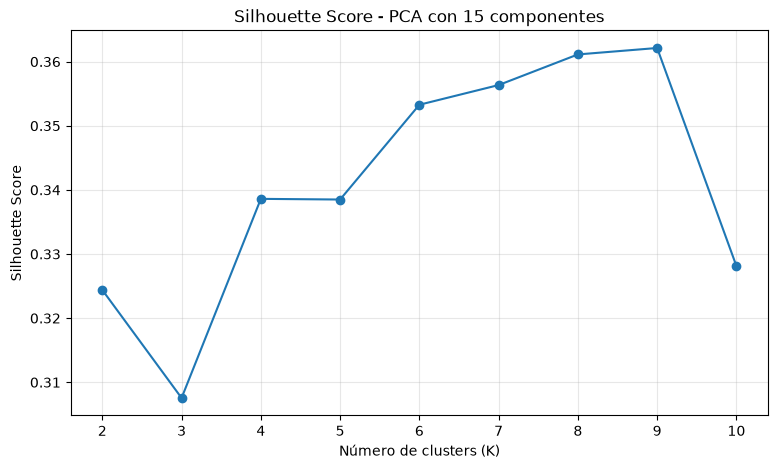

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)

plt.show()

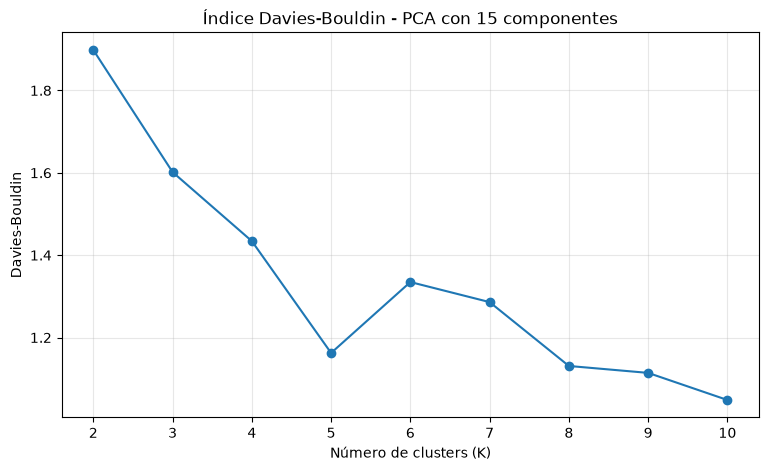

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)

plt.show()

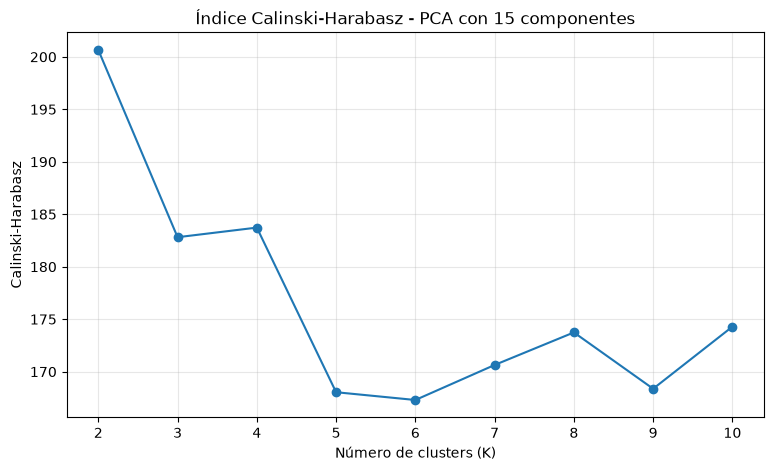

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)

plt.show()

In [16]:
resultados_tamano_15 = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_15)

    conteos = pd.Series(etiquetas).value_counts().sort_index()

    for cluster, cantidad in conteos.items():

        resultados_tamano_15.append({
            "K": k,
            "Cluster": cluster,
            "Observaciones": cantidad,
            "Porcentaje": cantidad / len(X_15) * 100
        })

tamano_clusters_15 = pd.DataFrame(resultados_tamano_15)

tamano_clusters_15

,K,Cluster,Observaciones,Porcentaje
0,2,0,889,73.653687
1,2,1,318,26.346313
2,3,0,895,74.150787
3,3,1,59,4.888152
4,3,2,253,20.961060
5,4,0,846,70.091135
6,4,1,251,20.795360
7,4,2,51,4.225352
8,4,3,59,4.888152
9,5,0,845,70.008285


In [17]:
tamano_minimo_15 = (
    tamano_clusters_15
    .groupby("K")["Porcentaje"]
    .min()
    .reset_index(name="Porcentaje_cluster_minimo")
)

tamano_minimo_15.round(4)

,K,Porcentaje_cluster_minimo
0,2,26.3463
1,3,4.8882
2,4,4.2254
3,5,0.0829
4,6,0.2486
5,7,0.3314
6,8,0.0829
7,9,0.0829
8,10,0.0829


In [48]:
semillas = [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]

resultados_estabilidad_15 = []

for k in range(2, 11):

    for semilla in semillas:

        modelo = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X_15)

        resultados_estabilidad_15.append({
            "K": k,
            "Semilla": semilla,
            "Silhouette": silhouette_score(X_15, etiquetas),
            "Davies-Bouldin": davies_bouldin_score(X_15, etiquetas),
            "Calinski-Harabasz": calinski_harabasz_score(X_15, etiquetas)
        })

estabilidad_15 = pd.DataFrame(resultados_estabilidad_15)

estabilidad_15.round(4)

,K,Semilla,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0,0.3497,1.7282,234.6548
1,2,1,0.3497,1.7282,234.6548
2,2,2,0.3497,1.7282,234.6548
3,2,3,0.3504,1.7282,234.6547
4,2,4,0.3497,1.7282,234.6548
...,...,...,...,...,...
85,10,5,0.3898,0.8665,235.4647
86,10,10,0.4218,0.9356,233.4910
87,10,20,0.4189,0.8481,231.0027
88,10,42,0.4116,0.8721,233.6120


In [49]:
resumen_estabilidad_15 = (
    estabilidad_15
    .groupby("K")
    .agg(
        Silhouette_media=("Silhouette", "mean"),
        Silhouette_std=("Silhouette", "std"),

        Davies_Bouldin_media=("Davies-Bouldin", "mean"),
        Davies_Bouldin_std=("Davies-Bouldin", "std"),

        Calinski_Harabasz_media=("Calinski-Harabasz", "mean"),
        Calinski_Harabasz_std=("Calinski-Harabasz", "std")
    )
    .reset_index()
)

resumen_estabilidad_15.round(4)

,K,Silhouette_media,Silhouette_std,Davies_Bouldin_media,Davies_Bouldin_std,Calinski_Harabasz_media,Calinski_Harabasz_std
0,2,0.3499,0.0003,1.7282,0.0000,234.6548,0.0000
1,3,0.3381,0.0015,1.4439,0.0018,217.8322,0.1525
2,4,0.3751,0.0000,1.2959,0.0000,223.8759,0.0000
3,5,0.3896,0.0040,1.3208,0.0967,219.2262,3.9999
4,6,0.3935,0.0104,1.1947,0.0799,213.8898,3.0017
5,7,0.3998,0.0120,1.1031,0.0468,215.3135,2.0016
6,8,0.3955,0.0162,0.9679,0.0318,224.1833,2.9254
7,9,0.4120,0.0122,0.9159,0.0438,233.7422,5.6509
8,10,0.4146,0.0129,0.8988,0.0335,236.2985,2.9439


In [52]:
resultados_ari_15 = []

for k in range(2, 11):

    etiquetas_modelos = []

    for semilla in semillas:

        modelo = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X_15)

        etiquetas_modelos.append(etiquetas)

    ari_pares = []

    for i in range(len(etiquetas_modelos)):

        for j in range(i + 1, len(etiquetas_modelos)):

            ari = adjusted_rand_score(
                etiquetas_modelos[i],
                etiquetas_modelos[j]
            )

            ari_pares.append(ari)

    resultados_ari_15.append({
        "K": k,
        "ARI_media": np.mean(ari_pares),
        "ARI_std": np.std(ari_pares),
        "ARI_min": np.min(ari_pares),
        "ARI_max": np.max(ari_pares)
    })

estabilidad_ari_15 = pd.DataFrame(resultados_ari_15)

estabilidad_ari_15.round(4)

,K,ARI_media,ARI_std,ARI_min,ARI_max
0,2,0.9988,0.0017,0.9965,1.0000
1,3,0.9915,0.0072,0.9794,1.0000
2,4,1.0000,0.0000,1.0000,1.0000
3,5,0.9606,0.0748,0.8092,1.0000
4,6,0.9106,0.0864,0.7684,1.0000
5,7,0.9182,0.0766,0.7748,1.0000
6,8,0.8800,0.0747,0.7746,1.0000
7,9,0.9376,0.0701,0.8062,1.0000
8,10,0.8926,0.0537,0.7950,0.9947


## Base con 11 Componentes Principales

In [59]:
base_pca_11 = pd.read_excel(
    "../data_processed/base_pca_pc11.xlsx", index_col=False
)

In [60]:
print(base_pca_11.shape)
print(base_pca_11.columns.tolist())

(1207, 14)
['ENTIDAD', 'AÑO', 'MES', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11']


In [61]:
componentes_11 = [f"PC{i}" for i in range(1, 12)]

X_11 = base_pca_11[componentes_11].copy()

In [62]:
X_11

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1.670347,0.502379,-0.042134,-0.416447,-0.400394,0.587995,0.064463,0.430966,0.177770,0.118118,-0.144951
1,-0.115299,1.558395,0.224663,-0.709588,-0.588966,-0.313117,-1.171159,-0.770303,-0.493599,0.053284,0.456153
2,1.156175,0.988809,0.026511,-0.498811,-0.637850,1.734359,0.260784,0.023163,0.391043,-0.580411,-0.289325
3,1.640124,0.536628,-0.123792,-0.298277,-0.054033,0.720321,0.466976,0.166415,0.156370,0.035833,-0.111220
4,0.613685,1.255829,-0.521423,-0.107043,-0.267869,0.702814,-0.521423,0.085350,0.032167,0.346015,0.002496
...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036050,0.227408,-1.546625,0.695162,-0.837071,0.741944,0.968608,0.628594,0.188701,1.542611,-0.235439
1203,-2.120454,-2.090060,2.385573,-0.537103,-0.373360,-1.267025,-1.235365,-0.126987,-0.825938,1.035732,0.754084
1204,1.424948,-1.549647,-4.348830,1.904234,-0.426342,0.884789,2.074180,0.699166,0.064172,1.067329,-0.093991
1205,-0.057926,1.335615,0.959661,-0.750775,0.050468,0.373882,-0.449840,0.709407,0.316070,-0.246258,-0.183795


In [63]:
print("Valores nulos:", X_11.isna().sum().sum())

Valores nulos: 0


In [64]:
resultados_k_11 = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_11)

    resultados_k_11.append({
        "K": k,
        "Silhouette": silhouette_score(X_11, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(X_11, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(X_11, etiquetas)
    })

resultados_k_11 = pd.DataFrame(resultados_k_11)

resultados_k_11

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.349723,1.728227,234.654791
1,3,0.340588,1.441399,217.873669
2,4,0.375052,1.295895,223.875856
3,5,0.391767,1.350903,220.603988
4,6,0.400485,1.293821,210.463903
5,7,0.406958,1.116326,215.409797
6,8,0.410606,0.978456,225.301310
7,9,0.417642,0.894272,235.870952
8,10,0.411634,0.872149,233.612010


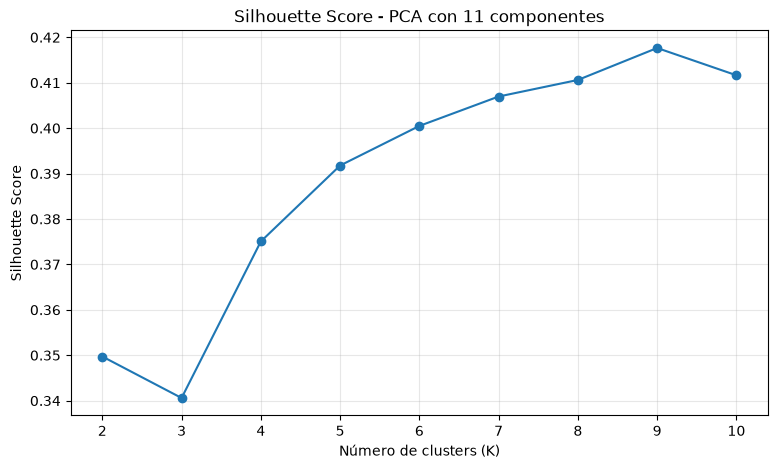

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)

plt.show()

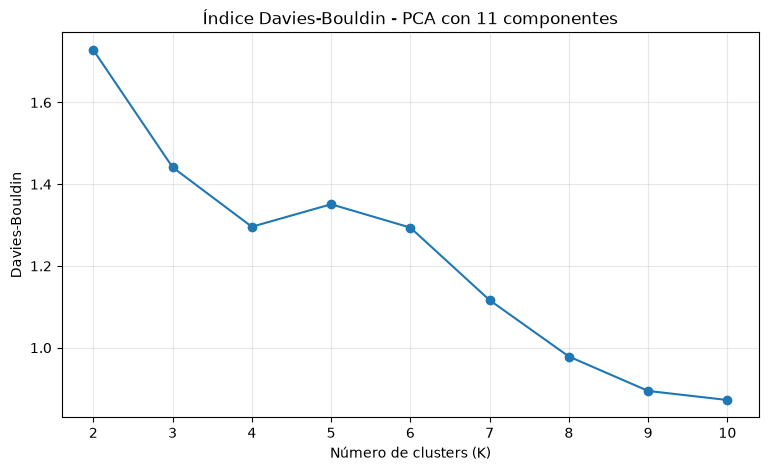

In [66]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)

plt.show()

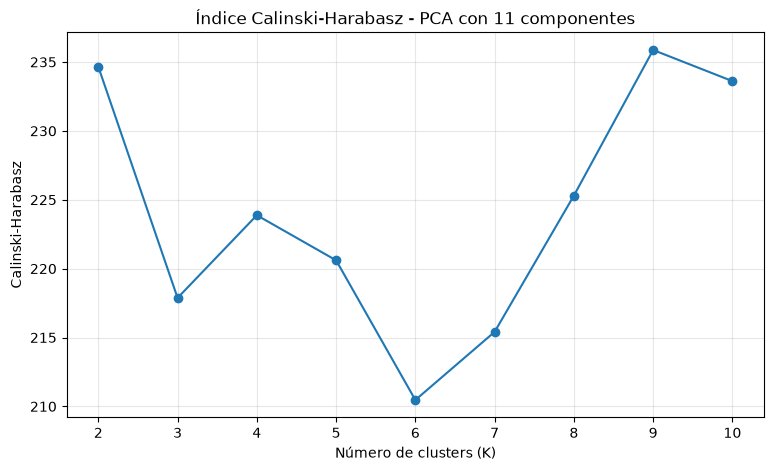

In [67]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)

plt.show()

In [68]:
resultados_tamano_11 = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_11)

    conteos = pd.Series(etiquetas).value_counts().sort_index()

    for cluster, cantidad in conteos.items():

        resultados_tamano_11.append({
            "K": k,
            "Cluster": cluster,
            "Observaciones": cantidad,
            "Porcentaje": cantidad / len(X_11) * 100
        })

tamano_clusters_11 = pd.DataFrame(resultados_tamano_11)

tamano_clusters_11

,K,Cluster,Observaciones,Porcentaje
0,2,0,323,26.760563
1,2,1,884,73.239437
2,3,0,890,73.736537
3,3,1,61,5.053853
4,3,2,256,21.209611
5,4,0,839,69.511185
6,4,1,256,21.209611
7,4,2,61,5.053853
8,4,3,51,4.225352
9,5,0,95,7.870754


In [69]:
tamano_minimo_11 = (
    tamano_clusters_11
    .groupby("K")["Porcentaje"]
    .min()
    .reset_index(name="Porcentaje_cluster_minimo")
)

tamano_minimo_11.round(4)

,K,Porcentaje_cluster_minimo
0,2,26.7606
1,3,5.0539
2,4,4.2254
3,5,4.2254
4,6,4.2254
5,7,0.3314
6,8,0.0829
7,9,0.0829
8,10,0.0829


In [70]:
semillas = [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]

resultados_estabilidad_11 = []

for k in range(2, 11):

    for semilla in semillas:

        modelo = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X_11)

        resultados_estabilidad_11.append({
            "K": k,
            "Semilla": semilla,
            "Silhouette": silhouette_score(X_11, etiquetas),
            "Davies-Bouldin": davies_bouldin_score(X_11, etiquetas),
            "Calinski-Harabasz": calinski_harabasz_score(X_11, etiquetas)
        })

estabilidad_11 = pd.DataFrame(resultados_estabilidad_11)

estabilidad_11.round(4)

,K,Semilla,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0,0.3497,1.7282,234.6548
1,2,1,0.3497,1.7282,234.6548
2,2,2,0.3497,1.7282,234.6548
3,2,3,0.3504,1.7282,234.6547
4,2,4,0.3497,1.7282,234.6548
...,...,...,...,...,...
85,10,5,0.3898,0.8665,235.4647
86,10,10,0.4218,0.9356,233.4910
87,10,20,0.4189,0.8481,231.0027
88,10,42,0.4116,0.8721,233.6120


In [71]:
resumen_estabilidad_11 = (
    estabilidad_11
    .groupby("K")
    .agg(
        Silhouette_media=("Silhouette", "mean"),
        Silhouette_std=("Silhouette", "std"),

        Davies_Bouldin_media=("Davies-Bouldin", "mean"),
        Davies_Bouldin_std=("Davies-Bouldin", "std"),

        Calinski_Harabasz_media=("Calinski-Harabasz", "mean"),
        Calinski_Harabasz_std=("Calinski-Harabasz", "std")
    )
    .reset_index()
)

resumen_estabilidad_11.round(4)

,K,Silhouette_media,Silhouette_std,Davies_Bouldin_media,Davies_Bouldin_std,Calinski_Harabasz_media,Calinski_Harabasz_std
0,2,0.3499,0.0003,1.7282,0.0000,234.6548,0.0000
1,3,0.3381,0.0015,1.4439,0.0018,217.8322,0.1525
2,4,0.3751,0.0000,1.2959,0.0000,223.8759,0.0000
3,5,0.3896,0.0040,1.3208,0.0967,219.2262,3.9999
4,6,0.3935,0.0104,1.1947,0.0799,213.8898,3.0017
5,7,0.3998,0.0120,1.1031,0.0468,215.3135,2.0016
6,8,0.3955,0.0162,0.9679,0.0318,224.1833,2.9254
7,9,0.4120,0.0122,0.9159,0.0438,233.7422,5.6509
8,10,0.4146,0.0129,0.8988,0.0335,236.2985,2.9439


In [72]:
resultados_ari_11 = []

for k in range(2, 11):

    etiquetas_modelos = []

    for semilla in semillas:

        modelo = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X_11)

        etiquetas_modelos.append(etiquetas)

    ari_pares = []

    for i in range(len(etiquetas_modelos)):

        for j in range(i + 1, len(etiquetas_modelos)):

            ari = adjusted_rand_score(
                etiquetas_modelos[i],
                etiquetas_modelos[j]
            )

            ari_pares.append(ari)

    resultados_ari_11.append({
        "K": k,
        "ARI_media": np.mean(ari_pares),
        "ARI_std": np.std(ari_pares),
        "ARI_min": np.min(ari_pares),
        "ARI_max": np.max(ari_pares)
    })

estabilidad_ari_11 = pd.DataFrame(resultados_ari_11)

estabilidad_ari_11.round(4)

,K,ARI_media,ARI_std,ARI_min,ARI_max
0,2,0.9988,0.0017,0.9965,1.0000
1,3,0.9915,0.0072,0.9794,1.0000
2,4,1.0000,0.0000,1.0000,1.0000
3,5,0.9606,0.0748,0.8092,1.0000
4,6,0.9106,0.0864,0.7684,1.0000
5,7,0.9182,0.0766,0.7748,1.0000
6,8,0.8800,0.0747,0.7746,1.0000
7,9,0.9376,0.0701,0.8062,1.0000
8,10,0.8926,0.0537,0.7950,0.9947


In [73]:
verificacion_ari = []

for k in range(2, 11):

    modelo_15 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_11 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas_15 = modelo_15.fit_predict(X_15)
    etiquetas_11 = modelo_11.fit_predict(X_11)

    ari_entre_pca = adjusted_rand_score(
        etiquetas_15,
        etiquetas_11
    )

    verificacion_ari.append({
        "K": k,
        "ARI_PC15_vs_PC11": ari_entre_pca
    })

verificacion_ari = pd.DataFrame(verificacion_ari)

verificacion_ari.round(4)

,K,ARI_PC15_vs_PC11
0,2,1.0
1,3,1.0
2,4,1.0
3,5,1.0
4,6,1.0
5,7,1.0
6,8,1.0
7,9,1.0
8,10,1.0


In [74]:
comparacion_pca_semillas = []

for k in range(2, 11):

    for semilla in semillas:

        modelo_15 = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        modelo_11 = KMeans(
            n_clusters=k,
            random_state=semilla,
            n_init=10
        )

        etiquetas_15 = modelo_15.fit_predict(X_15)
        etiquetas_11 = modelo_11.fit_predict(X_11)

        ari = adjusted_rand_score(
            etiquetas_15,
            etiquetas_11
        )

        comparacion_pca_semillas.append({
            "K": k,
            "Semilla": semilla,
            "ARI_PC15_vs_PC11": ari
        })

comparacion_pca_semillas = pd.DataFrame(comparacion_pca_semillas)

comparacion_pca_semillas.round(4)

,K,Semilla,ARI_PC15_vs_PC11
0,2,0,1.0
1,2,1,1.0
2,2,2,1.0
3,2,3,1.0
4,2,4,1.0
...,...,...,...
85,10,5,1.0
86,10,10,1.0
87,10,20,1.0
88,10,42,1.0


In [75]:
resumen_comparacion_pca = (
    comparacion_pca_semillas
    .groupby("K")["ARI_PC15_vs_PC11"]
    .agg(
        ARI_media="mean",
        ARI_std="std",
        ARI_min="min",
        ARI_max="max"
    )
    .reset_index()
)

resumen_comparacion_pca.round(4)

,K,ARI_media,ARI_std,ARI_min,ARI_max
0,2,1.0,0.0,1.0,1.0
1,3,1.0,0.0,1.0,1.0
2,4,1.0,0.0,1.0,1.0
3,5,1.0,0.0,1.0,1.0
4,6,1.0,0.0,1.0,1.0
5,7,1.0,0.0,1.0,1.0
6,8,1.0,0.0,1.0,1.0
7,9,1.0,0.0,1.0,1.0
8,10,1.0,0.0,1.0,1.0


Comparación de las representaciones PCA. Se evaluaron dos representaciones del espacio reducido, correspondientes a las primeras 11 y 15 componentes principales, que explican aproximadamente el 80% y 91% de la varianza total, respectivamente. Los resultados mostraron que la representación con 11 componentes presentó, en general, mejores índices internos de calidad del clustering. Adicionalmente, mediante el Adjusted Rand Index se compararon las particiones obtenidas con ambas representaciones para valores de \(K\) entre 2 y 10 y diez inicializaciones diferentes. En todos los casos se obtuvo un ARI igual a 1, evidenciando que la incorporación de las componentes 12 a 15 no modificó la asignación de las observaciones a los grupos. En consecuencia, la representación de 11 componentes constituye una alternativa más parsimoniosa para la etapa de clustering, al mantener las mismas particiones identificadas con 15 componentes utilizando un menor número de dimensiones.

In [76]:
k_candidatos = [4, 5, 6, 7]

comparacion_k = resultados_k_11[
    resultados_k_11["K"].isin(k_candidatos)
].copy()

comparacion_k

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
2,4,0.375052,1.295895,223.875856
3,5,0.391767,1.350903,220.603988
4,6,0.400485,1.293821,210.463903
5,7,0.406958,1.116326,215.409797


In [77]:
# Orden según Silhouette
comparacion_k.sort_values(
    "Silhouette",
    ascending=False
)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
5,7,0.406958,1.116326,215.409797
4,6,0.400485,1.293821,210.463903
3,5,0.391767,1.350903,220.603988
2,4,0.375052,1.295895,223.875856


In [78]:
# Orden según Davies-Bouldin
comparacion_k.sort_values(
    "Davies-Bouldin",
    ascending=True
)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
5,7,0.406958,1.116326,215.409797
4,6,0.400485,1.293821,210.463903
2,4,0.375052,1.295895,223.875856
3,5,0.391767,1.350903,220.603988


In [79]:
# Orden según Calinski-Harabasz
comparacion_k.sort_values(
    "Calinski-Harabasz",
    ascending=False
)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
2,4,0.375052,1.295895,223.875856
3,5,0.391767,1.350903,220.603988
5,7,0.406958,1.116326,215.409797
4,6,0.400485,1.293821,210.463903


In [80]:
k_candidatos = [4, 5, 6, 7]

tabla_comparacion_k = (
    resultados_k_11[
        resultados_k_11["K"].isin(k_candidatos)
    ]
    .merge(
        tamano_minimo_11[
            tamano_minimo_11["K"].isin(k_candidatos)
        ],
        on="K",
        how="left"
    )
    .merge(
        estabilidad_ari_11[
            estabilidad_ari_11["K"].isin(k_candidatos)
        ][["K", "ARI_media", "ARI_std", "ARI_min"]],
        on="K",
        how="left"
    )
)

tabla_comparacion_k.round(4)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz,Porcentaje_cluster_minimo,ARI_media,ARI_std,ARI_min
0,4,0.3751,1.2959,223.8759,4.2254,1.0000,0.0000,1.0000
1,5,0.3918,1.3509,220.6040,4.2254,0.9606,0.0748,0.8092
2,6,0.4005,1.2938,210.4639,4.2254,0.9106,0.0864,0.7684
3,7,0.4070,1.1163,215.4098,0.3314,0.9182,0.0766,0.7748


Para determinar el número de grupos se evaluaron las soluciones de K-Means para \(K=4,5,6\) y \(7\), utilizando los índices Silhouette, Davies-Bouldin y Calinski-Harabasz, complementados con el tamaño mínimo de los grupos y la estabilidad de las soluciones mediante el índice Adjusted Rand Index (ARI). Los resultados muestran que la solución con \(K=7\) presenta los mejores valores de Silhouette (0,4070) y Davies-Bouldin (1,1163); sin embargo, genera un cluster que representa únicamente el 0,33% de las observaciones, lo que evidencia la formación de un grupo extremadamente pequeño. Por otra parte, la solución con \(K=4\) presenta el mayor valor del índice Calinski-Harabasz (223,8759) y alcanza una estabilidad perfecta entre las diferentes semillas evaluadas (ARI medio = 1,0000; desviación estándar = 0,0000; ARI mínimo = 1,0000). Adicionalmente, su grupo de menor tamaño representa el 4,23% de las observaciones. En conjunto, estos resultados indican que, aunque soluciones con un mayor número de clusters presentan una mejora en algunas métricas de separación, \(K=4\) ofrece un compromiso más adecuado entre calidad del agrupamiento, estabilidad y distribución equilibrada de las observaciones. Por este motivo, se selecciona \(K=4\) como solución principal para la identificación de los perfiles financieros.

In [81]:
from sklearn.cluster import KMeans


kmeans_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Asignación de clusters
clusters_k4 = kmeans_k4.fit_predict(X_11)

# Agregar la etiqueta del cluster
base_cluster_k4 = base_pca_11.copy()
base_cluster_k4["CLUSTER"] = clusters_k4

In [82]:
conteo_clusters = (
    base_cluster_k4["CLUSTER"]
    .value_counts()
    .sort_index()
)

conteo_clusters

CLUSTER
0    839
1    256
2     61
3     51
Name: count, dtype: int64

In [83]:
porcentaje_clusters = (
    base_cluster_k4["CLUSTER"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

porcentaje_clusters

CLUSTER
0    69.511185
1    21.209611
2     5.053853
3     4.225352
Name: proportion, dtype: float64

In [84]:
base_cluster_k4["CLUSTER"].isna().sum()

np.int64(0)

In [85]:
base_cluster_k4

,ENTIDAD,AÑO,MES,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,CLUSTER
0,BP GUAYAQUIL,2022,Mayo,1.670347,0.502379,-0.042134,-0.416447,-0.400394,0.587995,0.064463,0.430966,0.177770,0.118118,-0.144951,0
1,BP PACIFICO,2022,Mayo,-0.115299,1.558395,0.224663,-0.709588,-0.588966,-0.313117,-1.171159,-0.770303,-0.493599,0.053284,0.456153,0
2,BP PICHINCHA,2022,Mayo,1.156175,0.988809,0.026511,-0.498811,-0.637850,1.734359,0.260784,0.023163,0.391043,-0.580411,-0.289325,0
3,BP PRODUBANCO,2022,Mayo,1.640124,0.536628,-0.123792,-0.298277,-0.054033,0.720321,0.466976,0.166415,0.156370,0.035833,-0.111220,0
4,BP AUSTRO,2022,Mayo,0.613685,1.255829,-0.521423,-0.107043,-0.267869,0.702814,-0.521423,0.085350,0.032167,0.346015,0.002496,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,BP CAPITAL,2026,Julio,1.036050,0.227408,-1.546625,0.695162,-0.837071,0.741944,0.968608,0.628594,0.188701,1.542611,-0.235439,0
1203,BP DELBANK,2026,Julio,-2.120454,-2.090060,2.385573,-0.537103,-0.373360,-1.267025,-1.235365,-0.126987,-0.825938,1.035732,0.754084,1
1204,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,2026,Julio,1.424948,-1.549647,-4.348830,1.904234,-0.426342,0.884789,2.074180,0.699166,0.064172,1.067329,-0.093991,0
1205,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",2026,Julio,-0.057926,1.335615,0.959661,-0.750775,0.050468,0.373882,-0.449840,0.709407,0.316070,-0.246258,-0.183795,0


In [87]:
# Diccionario para convertir los meses en español a número
meses = {
    "ENERO": 1,
    "FEBRERO": 2,
    "MARZO": 3,
    "ABRIL": 4,
    "MAYO": 5,
    "JUNIO": 6,
    "JULIO": 7,
    "AGOSTO": 8,
    "SEPTIEMBRE": 9,
    "OCTUBRE": 10,
    "NOVIEMBRE": 11,
    "DICIEMBRE": 12
}

# Convertir MES a mayúsculas y luego a número
base_cluster_k4["MES_NUM"] = (
    base_cluster_k4["MES"]
    .str.upper()
    .str.strip()
    .map(meses)
)

# Construir la fecha usando año y mes
base_cluster_k4["FECHA"] = pd.to_datetime(
    dict(
        year=base_cluster_k4["AÑO"],
        month=base_cluster_k4["MES_NUM"],
        day=1
    )
)

In [88]:
entidades = sorted(
    base_cluster_k4["ENTIDAD"].unique()
)

mapa_entidades = {
    entidad: i
    for i, entidad in enumerate(entidades)
}

base_cluster_k4["POS_ENTIDAD"] = (
    base_cluster_k4["ENTIDAD"]
    .map(mapa_entidades)
)

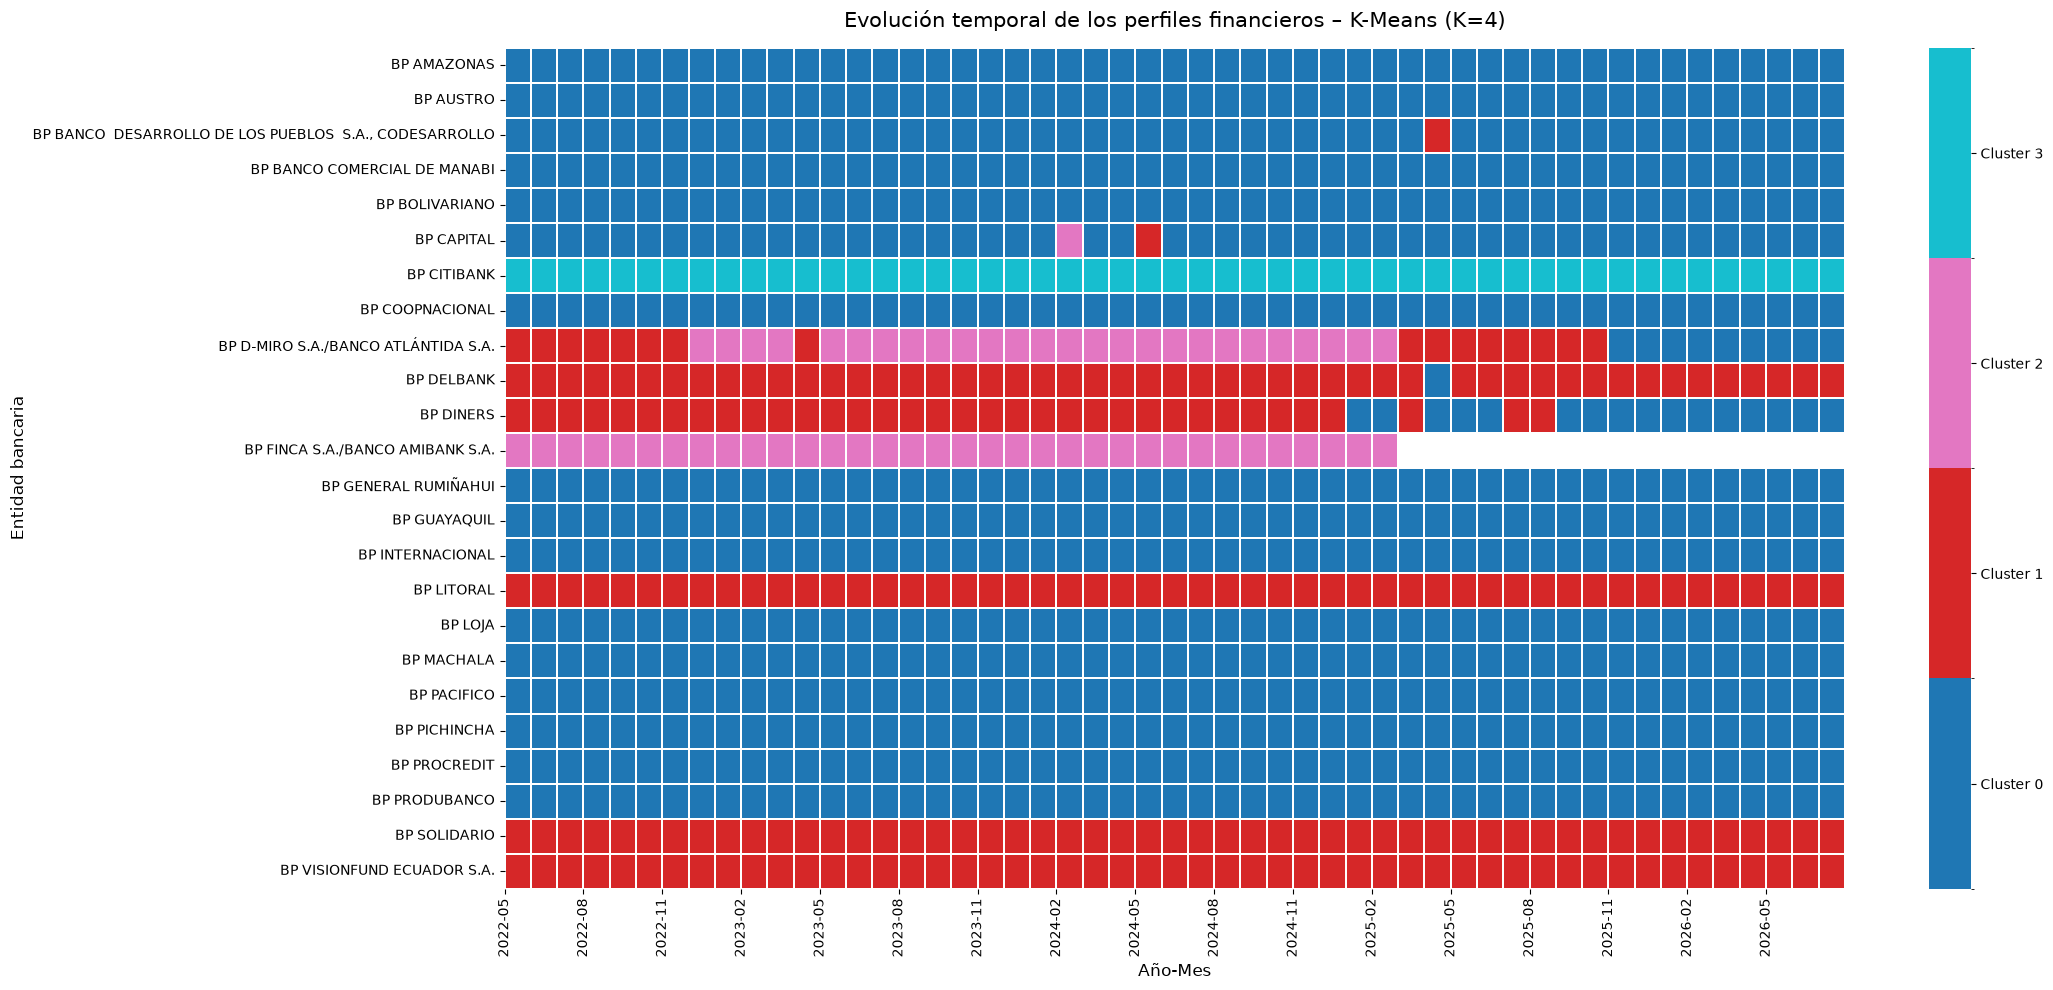

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# ============================================================
# 1. Copia de trabajo
# ============================================================

df_heatmap = base_cluster_k4.copy()

# Asegurar que FECHA sea datetime
df_heatmap["FECHA"] = pd.to_datetime(df_heatmap["FECHA"])

# Orden cronológico
df_heatmap = df_heatmap.sort_values(
    ["FECHA", "ENTIDAD"]
)

# ============================================================
# 2. Crear matriz de clusters
# ============================================================

matriz_clusters = df_heatmap.pivot(
    index="ENTIDAD",
    columns="FECHA",
    values="CLUSTER"
)

# ============================================================
# 3. Definir colores discretos para los clusters
# ============================================================

# Un color específico para cada cluster
colores = [
    "#1f77b4",  # Cluster 0
    "#d62728",  # Cluster 1
    "#e377c2",  # Cluster 2
    "#17becf"   # Cluster 3
]

cmap = ListedColormap(colores)

# Límites para que cada color corresponda exactamente
# a un cluster: 0, 1, 2 y 3
norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap.N
)

# ============================================================
# 4. Crear gráfico
# ============================================================

plt.figure(figsize=(22, 10))

ax = sns.heatmap(
    matriz_clusters,
    cmap=cmap,
    norm=norm,
    cbar=True,
    linewidths=0.2,
    linecolor="white"
)

# ============================================================
# 5. Configurar eje X como Año-Mes
# ============================================================

# Mostrar una etiqueta cada 3 meses
posiciones = range(0, len(matriz_clusters.columns), 3)

etiquetas = [
    fecha.strftime("%Y-%m")
    for fecha in matriz_clusters.columns[posiciones]
]

ax.set_xticks(posiciones)
ax.set_xticklabels(
    etiquetas,
    rotation=90,
    ha="center"
)

# ============================================================
# 6. Configurar barra de color
# ============================================================

colorbar = ax.collections[0].colorbar

colorbar.set_ticks([0, 1, 2, 3])
colorbar.set_ticklabels([
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3"
])

# ============================================================
# 7. Títulos y etiquetas
# ============================================================

plt.title(
    "Evolución temporal de los perfiles financieros – K-Means (K=4)",
    fontsize=15,
    pad=15
)

plt.xlabel("Año-Mes", fontsize=12)
plt.ylabel("Entidad bancaria", fontsize=12)

plt.tight_layout()
plt.show()

In [91]:
# Tabla de proporciones
proporcion_clusters = pd.crosstab(
    base_cluster_k4["ENTIDAD"],
    base_cluster_k4["CLUSTER"],
    normalize="index"
) * 100

# Asegurar que existan las 4 columnas
proporcion_clusters = proporcion_clusters.reindex(
    columns=[0, 1, 2, 3],
    fill_value=0
)

proporcion_clusters

CLUSTER,0,1,2,3
ENTIDAD,,,,
BP AMAZONAS,100.000000,0.000000,0.000000,0.0
BP AUSTRO,100.000000,0.000000,0.000000,0.0
"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., CODESARROLLO",98.039216,1.960784,0.000000,0.0
BP BANCO COMERCIAL DE MANABI,100.000000,0.000000,0.000000,0.0
BP BOLIVARIANO,100.000000,0.000000,0.000000,0.0
BP CAPITAL,96.078431,1.960784,1.960784,0.0
BP CITIBANK,0.000000,0.000000,0.000000,100.0
BP COOPNACIONAL,100.000000,0.000000,0.000000,0.0
BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,17.647059,31.372549,50.980392,0.0


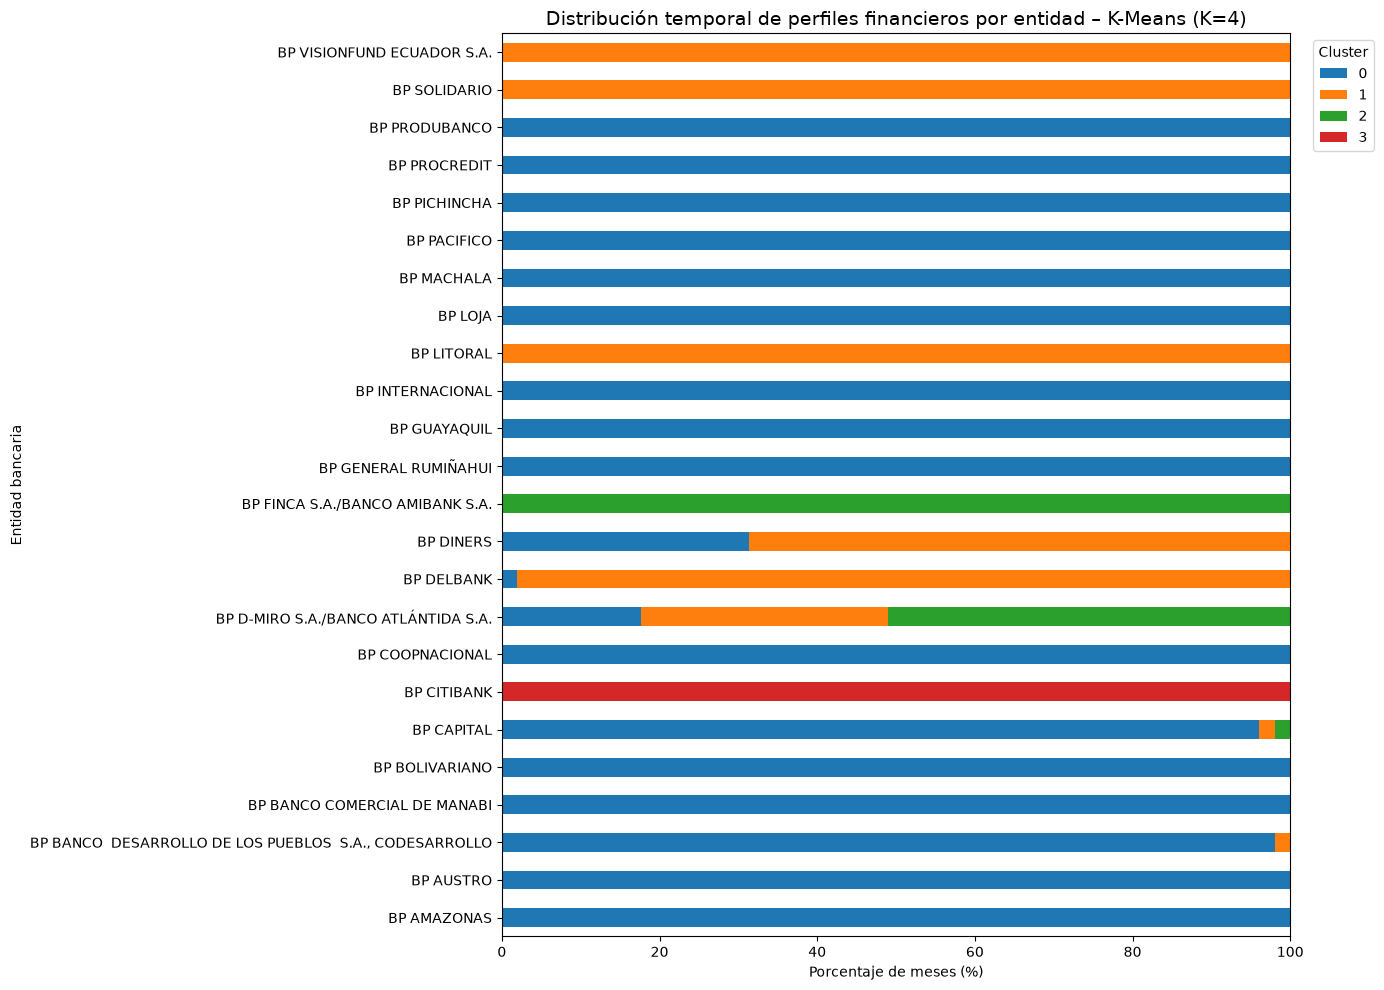

In [92]:
ax = proporcion_clusters.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 10)
)

plt.title(
    "Distribución temporal de perfiles financieros por entidad – K-Means (K=4)",
    fontsize=14
)

plt.xlabel("Porcentaje de meses (%)")
plt.ylabel("Entidad bancaria")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [96]:
base_final=pd.read_excel("../data_processed/base_pca.xlsx")

In [97]:
base_final

,MES,AÑO,ENTIDAD,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,...,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO,MES_NUM,FECHA
0,Mayo,2022,BP GUAYAQUIL,410.634510,8.120787,86.653465,120.426351,1.324103,81.951397,370.180856,...,0.527229,-15.357506,-3.105869,21.963595,10.850009,14.419397,16.334925,8.087612,5,2022-05-01
1,Mayo,2022,BP PACIFICO,276.006994,9.549144,78.284447,111.274525,3.081702,178.560615,227.330926,...,4.166759,-16.102362,15.214273,-0.671445,-0.215742,-3.749551,7.616585,2.003489,5,2022-05-01
2,Mayo,2022,BP PICHINCHA,-1288.206946,8.728095,91.272390,142.387866,2.408577,146.778509,134.752458,...,4.722154,-34.596167,0.889363,34.189556,10.684144,9.095698,17.660489,4.376836,5,2022-05-01
3,Mayo,2022,BP PRODUBANCO,345.788698,7.046035,88.058836,146.171009,1.442211,89.147317,198.464154,...,2.484534,-4.501507,-3.521776,24.150188,13.806515,9.297570,11.956282,7.797315,5,2022-05-01
4,Mayo,2022,BP AUSTRO,129.543127,7.715342,83.966638,104.258095,3.898154,60.387736,136.395986,...,2.783564,-15.937829,6.911905,21.409839,11.400689,7.823076,4.820617,12.813348,5,2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,Julio,2026,BP CAPITAL,74.360823,8.877858,79.688225,97.499072,4.329603,42.553501,183.484928,...,0.247529,-1.764260,54.532954,43.405379,32.243631,4.628479,44.564605,4.072887,7,2026-07-01
1203,Julio,2026,BP DELBANK,743.520441,28.876492,84.202134,176.981056,3.113181,77.719435,117.680006,...,0.384947,9.622450,-37.925514,-11.897364,-10.244491,-12.542475,-22.706797,5.183978,7,2026-07-01
1204,Julio,2026,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,78.836924,5.519091,87.180904,96.598989,2.152263,41.948642,193.089938,...,0.751003,139.889649,50.905153,78.103791,71.293760,27.512148,109.688042,-5.648516,7,2026-07-01
1205,Julio,2026,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",299.062134,10.365757,89.475107,106.919132,9.916992,94.215098,134.193628,...,0.662222,-58.597055,24.865624,3.694559,-5.187257,-13.838419,8.657541,6.703112,7,2026-07-01


In [99]:
columnas_id = ["ENTIDAD", "AÑO", "MES"]

base_caracterizacion = base_final.merge(
    base_cluster_k4[columnas_id + ["CLUSTER"]],
    on=columnas_id,
    how="inner"
)

In [100]:
base_caracterizacion

,MES,AÑO,ENTIDAD,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,...,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO,MES_NUM,FECHA,CLUSTER
0,Mayo,2022,BP GUAYAQUIL,410.634510,8.120787,86.653465,120.426351,1.324103,81.951397,370.180856,...,-15.357506,-3.105869,21.963595,10.850009,14.419397,16.334925,8.087612,5,2022-05-01,0
1,Mayo,2022,BP PACIFICO,276.006994,9.549144,78.284447,111.274525,3.081702,178.560615,227.330926,...,-16.102362,15.214273,-0.671445,-0.215742,-3.749551,7.616585,2.003489,5,2022-05-01,0
2,Mayo,2022,BP PICHINCHA,-1288.206946,8.728095,91.272390,142.387866,2.408577,146.778509,134.752458,...,-34.596167,0.889363,34.189556,10.684144,9.095698,17.660489,4.376836,5,2022-05-01,0
3,Mayo,2022,BP PRODUBANCO,345.788698,7.046035,88.058836,146.171009,1.442211,89.147317,198.464154,...,-4.501507,-3.521776,24.150188,13.806515,9.297570,11.956282,7.797315,5,2022-05-01,0
4,Mayo,2022,BP AUSTRO,129.543127,7.715342,83.966638,104.258095,3.898154,60.387736,136.395986,...,-15.937829,6.911905,21.409839,11.400689,7.823076,4.820617,12.813348,5,2022-05-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,Julio,2026,BP CAPITAL,74.360823,8.877858,79.688225,97.499072,4.329603,42.553501,183.484928,...,-1.764260,54.532954,43.405379,32.243631,4.628479,44.564605,4.072887,7,2026-07-01,0
1203,Julio,2026,BP DELBANK,743.520441,28.876492,84.202134,176.981056,3.113181,77.719435,117.680006,...,9.622450,-37.925514,-11.897364,-10.244491,-12.542475,-22.706797,5.183978,7,2026-07-01,1
1204,Julio,2026,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,78.836924,5.519091,87.180904,96.598989,2.152263,41.948642,193.089938,...,139.889649,50.905153,78.103791,71.293760,27.512148,109.688042,-5.648516,7,2026-07-01,0
1205,Julio,2026,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",299.062134,10.365757,89.475107,106.919132,9.916992,94.215098,134.193628,...,-58.597055,24.865624,3.694559,-5.187257,-13.838419,8.657541,6.703112,7,2026-07-01,0


In [101]:
# Variables que NO entran al PCA
variables_identificacion = [
    "ENTIDAD",
    "MES",
    "AÑO",
    "MES_NUM",
    "FECHA"
]


variables_pca = [
    col for col in base_final.columns
    if col not in variables_identificacion
]

In [102]:
perfil_clusters = (
    base_caracterizacion
    .groupby("CLUSTER")[variables_pca]
    .mean()
)

perfil_clusters

,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,COBERTURA DE LA CARTERA PROBLEMÁTICA,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),GASTOS DE OPERACION / MARGEN FINANCIERO,...,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO,CARTERA REFINANCIADA / CARTERA BRUTA,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO
CLUSTER,,,,,,,,,,,,,,,,,,,,,
0,107.447585,9.257407,86.699703,113.600280,3.442919e+00,119.154655,247.796741,5.685354e+02,4.035145,109.578797,...,27.452165,3.164320,1.779775,8.891151,22.049376,12.136216,12.004885,11.126991,18.458289,8.484983
1,746.290327,19.938174,89.776859,142.692688,6.110836e+00,87.291982,173.807503,1.370635e+02,9.187162,72.915901,...,36.270463,4.711321,1.958152,25.549343,15.602991,8.572559,7.728934,51.083177,15.769739,2.495395
2,98.817582,8.543502,81.347352,97.094729,2.011028e+01,55.786664,115.033426,6.988803e+01,9.752545,404.085889,...,36.392205,9.680208,6.008704,4.124691,73.019475,-17.173410,-7.807097,3.612899,2.832458,-14.633688
3,33628.715600,11.125935,85.806721,738.031516,4.743137e-07,0.000000,0.000000,1.236474e+09,3.712122,71.254704,...,31.508232,0.000000,0.209379,-7.947590,16.957643,15.582328,5.766489,6.264459,59848.855490,5.892101


In [103]:
perfil_estandarizado = (
    perfil_clusters - perfil_clusters.mean()
) / perfil_clusters.std()

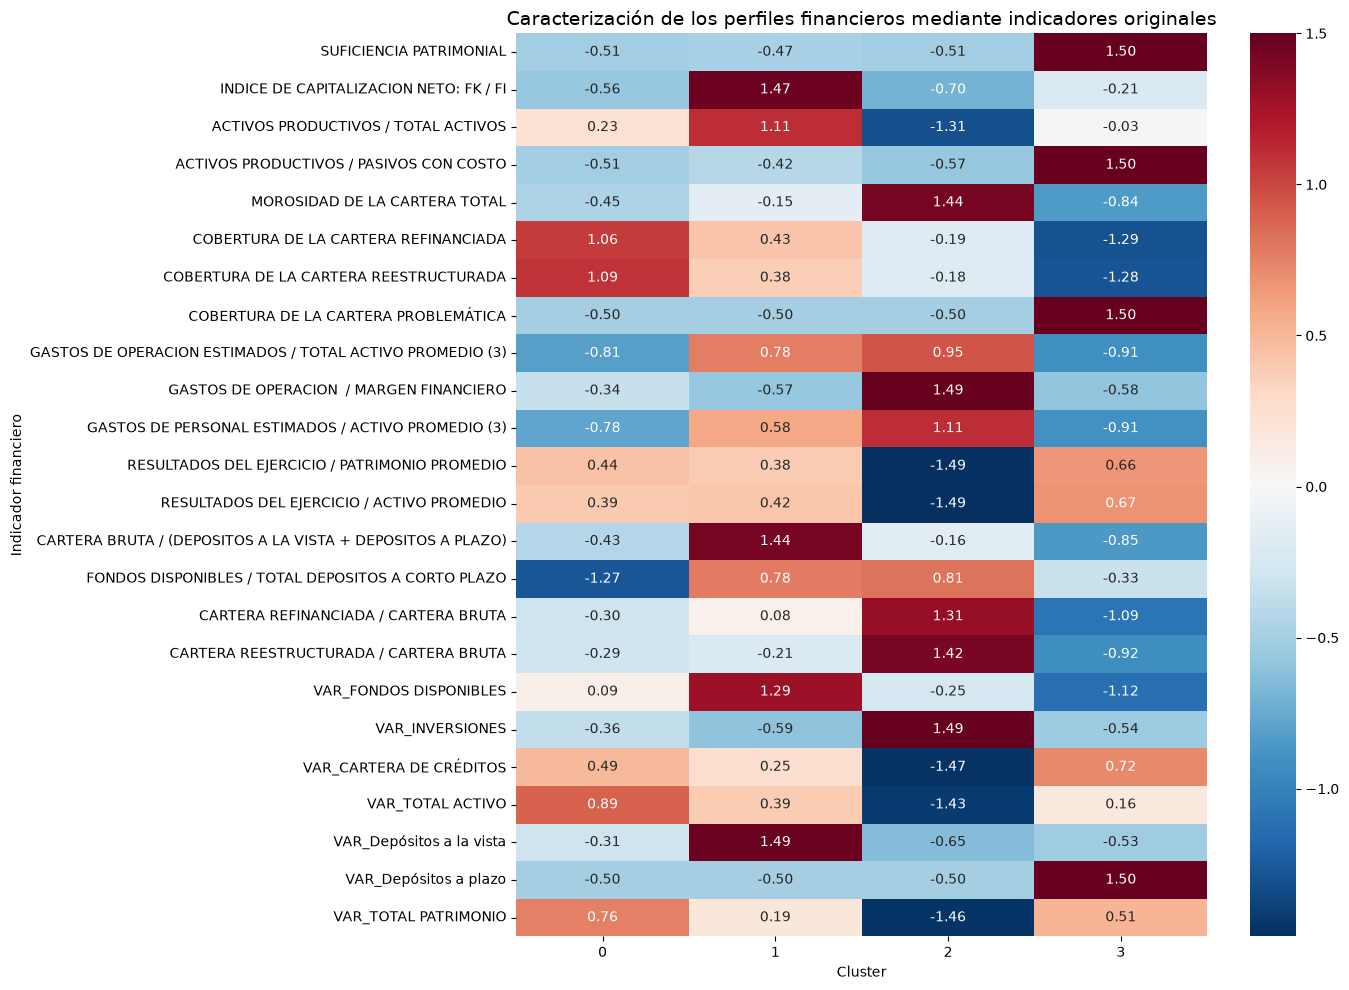

In [104]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    perfil_estandarizado.T,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu_r"
)

plt.xlabel("Cluster")
plt.ylabel("Indicador financiero")
plt.title(
    "Caracterización de los perfiles financieros mediante indicadores originales",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# Variables que más caracterizan a cada cluster
# ============================================================

for cluster in perfil_estandarizado.index:

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")

    perfil = perfil_estandarizado.loc[cluster].sort_values()

    print("\nIndicadores con valores MÁS BAJOS:")
    print(perfil.head(5))

    print("\nIndicadores con valores MÁS ALTOS:")
    print(perfil.tail(5).sort_values(ascending=False))


CLUSTER 0

Indicadores con valores MÁS BAJOS:
FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO          -1.271708
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)   -0.813289
GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)          -0.784398
INDICE DE CAPITALIZACION NETO: FK / FI                      -0.562322
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO                     -0.512583
Name: 0, dtype: float64

Indicadores con valores MÁS ALTOS:
COBERTURA DE LA CARTERA REESTRUCTURADA    1.085961
COBERTURA DE LA CARTERA REFINANCIADA      1.055293
VAR_TOTAL ACTIVO                          0.885752
VAR_TOTAL PATRIMONIO                      0.760466
VAR_CARTERA DE CRÉDITOS                   0.493334
Name: 0, dtype: float64

CLUSTER 1

Indicadores con valores MÁS BAJOS:
VAR_INVERSIONES                            -0.591849
GASTOS DE OPERACION  / MARGEN FINANCIERO   -0.569553
COBERTURA DE LA CARTERA PROBLEMÁTICA       -0.500000
VAR_Depósitos a plazo                      -0.499886
SUFIC